# International Football Match Outcome Prediction
## INFOH410 Project: Comparison of 3 AI Approaches

**Group 14:**
- Amine Bâaj
- Thierno Diallo
- Henock Mbolitumbalani Likoyo

**Goal**: predict the outcome of an international football match (Home win / Draw / Away win) using three different AI techniques:
1. **Naive Bayes**
2. **Decision Tree**
3. **Neural Network (MLP)**

---
## 1. Imports

We import the librairies needed.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 2. Loading the dataset

We use the "International Football Results from 1872 to 2026" dataset on Kaggle, a comprehensive collection of nearly 50,000 international football matches national teams.

Source: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

### 2.1 Dataset structure

The file `result.csv` contains one row per international match with the following columns:

|Column|Meaning|
|---|---|
|`date`|Date of the match (YYYY-MM-DD)|
|`home_team`|Name of the home team (e.g., "Brazil")|
|`away_team`|Name of the away team (e.g., "Germany")|
|`home_score`|Goals scored by the home team|
|`away_score`|Goals scored by the away team|
|`tournament`|Type of competition (e.g., "FIFA World Cup", "Friendly", "UEFA Euro qualification")|
|`city`|City where the match was played|
|`country`|Country where the match was played|
|`neutral`|`True` if played on neutral ground (no home advantage)|

In [2]:
DATA_PATH = '../data/results.csv'

# read the raw files and clean problematic commas (example: Washington, D.C.)
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    content = f.read()

# regex: find any "..., ..." pattern and remove the quotes + internal comma
content_clean = re.sub(r'"([^"]*),\s*([^"]*)"', r'\1 \2', content)

# save the cleaned version to a new file
CLEAN_PATH = '../data/results_clean.csv'
with open(CLEAN_PATH, 'w', encoding='utf-8') as f:
    f.write(content_clean)

# now load the cleaned CSV
df = pd.read_csv(CLEAN_PATH)

# basic info
print(f"Dataset loaded: {df.shape[0]} matches, {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} -> {df['date'].max()}\n")

df.head()

Dataset loaded: 49287 matches, 9 columns
Date range: 1872-11-30 -> 2026-06-27



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---
## 3. Data analysis

Before building any model, we explore the dataset to understand its structure, detect anomalies and motivate our preprocessing decisions.

### 3.1 Basic statistics and missing values

We first convert the `date` column to a proper datetime type, sort the data chronologically and check for missing values or anomalies.

In [3]:
# convert date column to datetime type 
df['date'] = pd.to_datetime(df['date'])

# sort chronoligically 
df = df.sort_values('date').reset_index(drop=True)

# check column types
print("Column types:")
print(df.dtypes)

# check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Missing values per column:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


## 3.2 Cleaning: removing matches without scores

The dataset contains 72 matches with missing scores, these are future matches scheduled but not played (e.g., upcoming 2026 World Cup).

In [4]:
# count rows before cleaning
n_before = len(df)

# remove matches with missing scores
df = df.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)

# convert scores back to integers
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)

n_after = len(df)

print(f"removed {n_before - n_after} matches with missing socres")
print(f"Final dataset: {n_after} matches")
print("\nUpdated column types:")
print(df.dtypes)

removed 72 matches with missing socres
Final dataset: 49215 matches

Updated column types:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object


### 3.3 Temporal coverage

The dataset covers than 150 years of international football. We analyze how matches are distributed over time on a relevant time window for our models.

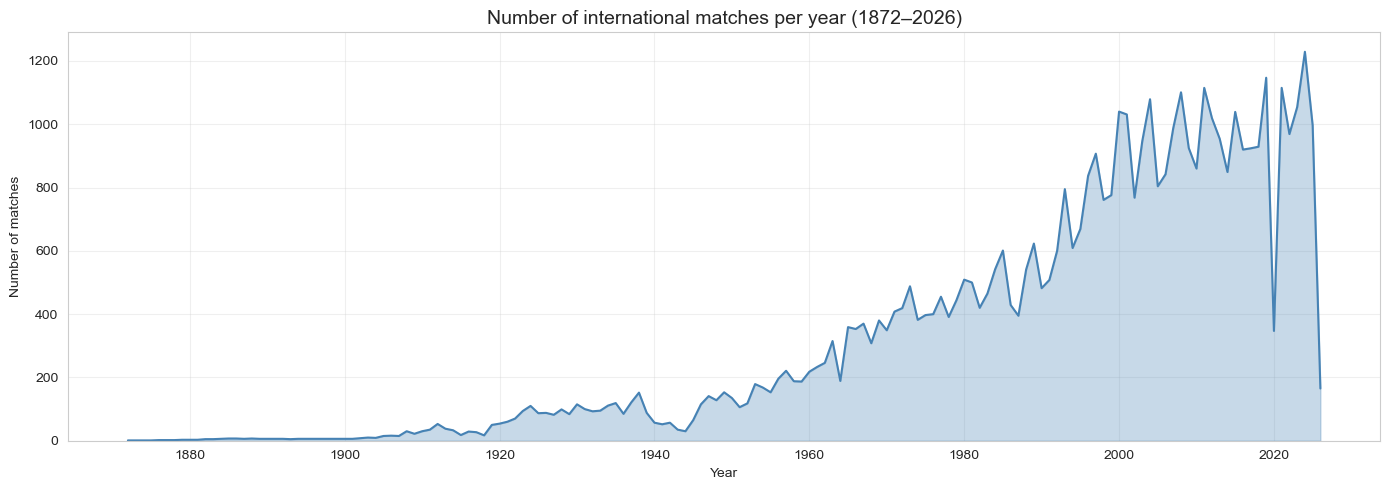

Total years covered: 154
Average matches per year: 318
Year with most matches: 2024 (1229 matches)
Year with fewest matches: 1872 (1 matches)


In [5]:
# extract year from each match
df['year'] = df['date'].dt.year

# count matches per year
matches_per_year = df.groupby('year').size()

# plot the distribution
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(matches_per_year.index, matches_per_year.values, color='steelblue', linewidth=1.5)
ax.fill_between(matches_per_year.index, matches_per_year.values, alpha=0.3, color='steelblue')

ax.set_title("Number of international matches per year (1872–2026)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_ylim(0,)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total years covered: {df['year'].max() - df['year'].min()}")
print(f"Average matches per year: {matches_per_year.mean():.0f}")
print(f"Year with most matches: {matches_per_year.idxmax()} ({matches_per_year.max()} matches)")
print(f"Year with fewest matches: {matches_per_year.idxmin()} ({matches_per_year.min()} matches)")

### 3.4 Distribution of match outcomes

We now derive our target variable `result` from the scores:
- `H` if `home_score > away_score` (Home win)
- `D` if `home_score == away_score` (Draw)
- `A` if `home_score < away_score` (Away win)

Analyzing the distribution of `result`reveals two phenomena:
1. **Home advantage:** teams playing at home tend to win more often
2. **Class imbalance:** draw are less frequent than wins

In [6]:
# derive the target variable from the scores
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'H'
    elif row['home_score'] < row['away_score']:
        return 'A'
    else:
        return 'D'

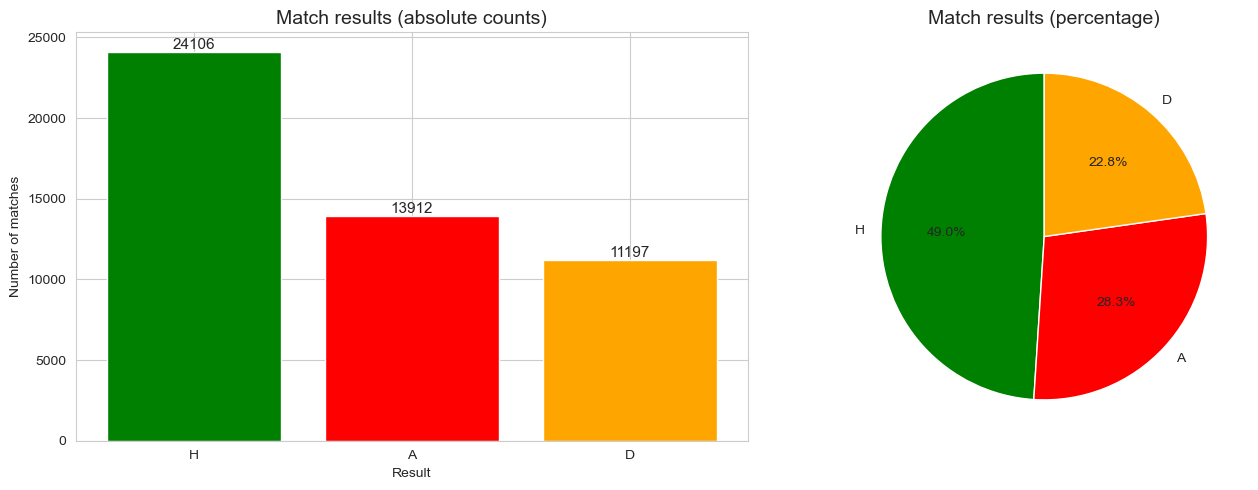

In [ ]:
result_values = ['H', 'D', 'A']

df['result'] = df.apply(get_result, axis=1)

# count the distribution
result_counts = df['result'].value_counts()
result_percentage = df['result'].value_counts(normalize=True) * 100

# plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
colors = {'H': 'green', 'D': 'orange', 'A': 'red'}
axes[0].bar(result_counts.index, result_counts.values, color=[colors[r] for r in result_counts.index])
axes[0].set_title("Match results (absolute counts)", fontsize=14)
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Number of matches")
for i, (r, v) in enumerate(result_counts.items()):
    axes[0].text(i, v + 200, f"{v}", ha='center', fontsize=11)

# pie chart
axes[1].pie(result_percentage.values, labels=result_percentage.index, colors=[colors[r] for r in result_percentage.index], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Match results (percentage)", fontsize=14)

plt.tight_layout()
plt.show()

### 3.5 Impact of neutral ground on home advantage

When a match is played on neutral ground (e.g., World Cup, continental cup), the labels "home" and "away" are arbitrary, there is no real home advantage. We expect the H/D/A distribution to be much more balanced for these matches. We should treat neutral matches differently to avoid teaching our models a false home advantage in these cases.

Matches with home advantage: 36239 (73.6%)
Matches on neutral ground: 12976 (26.4%)


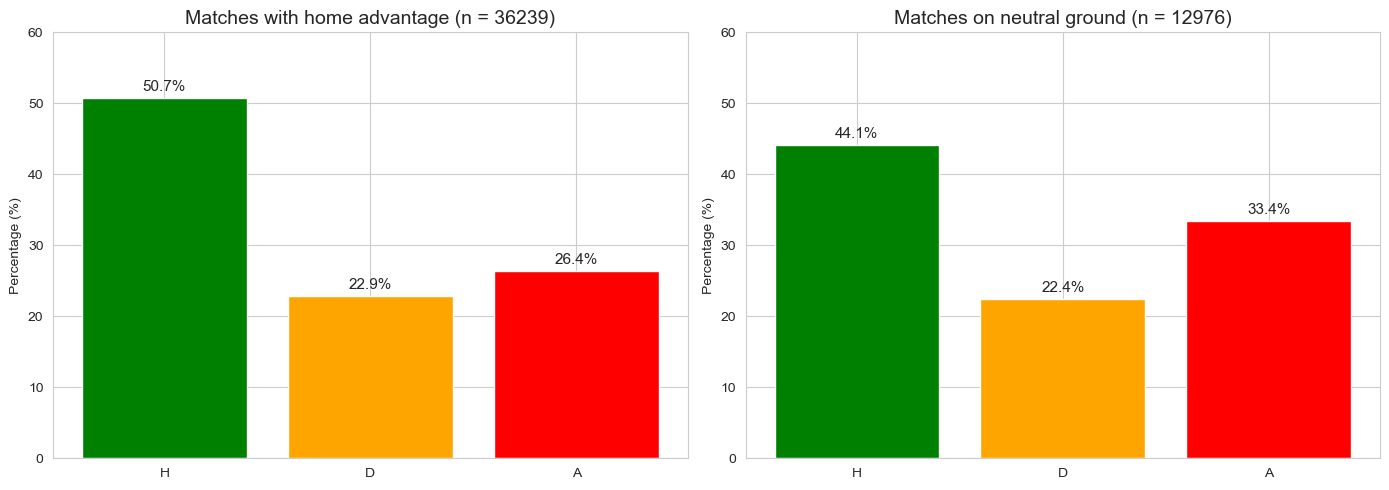

In [8]:
# split the dataset into neutral and non-neutral matches
df_home_advantage = df[df['neutral'] == False]
df_neutral = df[df['neutral'] == True]

print(f"Matches with home advantage: {len(df_home_advantage)} ({len(df_home_advantage)/len(df)*100:.1f}%)")
print(f"Matches on neutral ground: {len(df_neutral)} ({len(df_neutral)/len(df)*100:.1f}%)")

# compute distributions
percentage_home_adv = df_home_advantage['result'].value_counts(normalize=True) * 100
percentage_neutral = df_neutral['result'].value_counts(normalize=True) * 100

# comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# non-neutral
axes[0].bar(result_values, [percentage_home_adv.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[0].set_title(f"Matches with home advantage (n = {len(df_home_advantage)})", fontsize=14)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[0].text(i, percentage_home_adv.get(r, 0) + 1, f"{percentage_home_adv.get(r, 0):.1f}%", ha='center', fontsize=11)

# neutral
axes[1].bar(result_values, [percentage_neutral.get(r, 0) for r in result_values], color=[colors[r] for r in result_values])
axes[1].set_title(f"Matches on neutral ground (n = {len(df_neutral)})", fontsize=14)
axes[1].set_ylabel("Percentage (%)")
axes[1].set_ylim(0, 60)
for i, r in enumerate(result_values):
    axes[1].text(i, percentage_neutral.get(r, 0) + 1, f"{percentage_neutral.get(r, 0):.1f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### 3.6 Goal distribution

We analyze how many goals are typically scored in international matches.

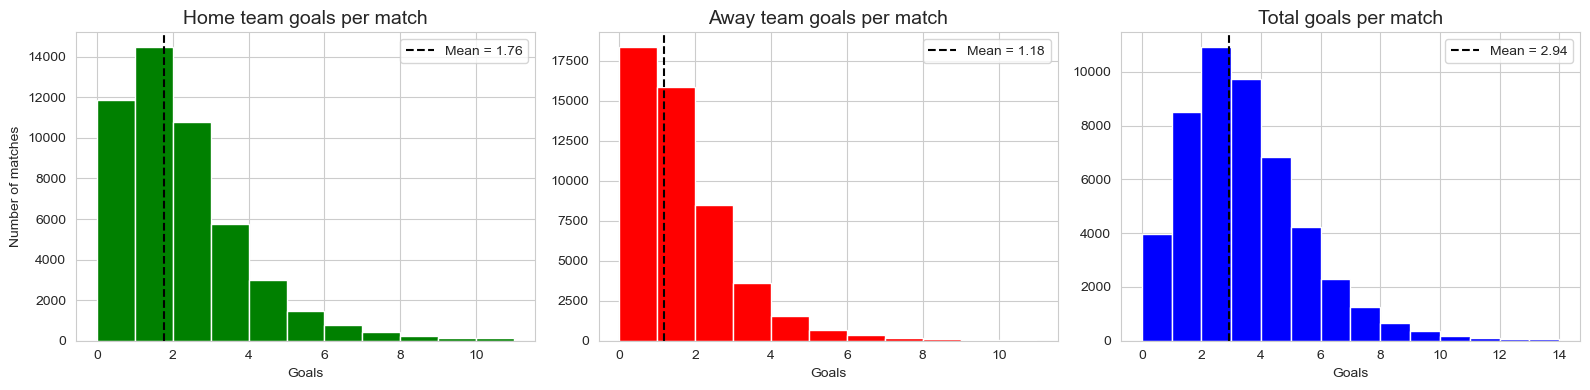


Most extreme matches:
      date home_team      away_team  home_score  away_score  total_goals
2001-04-11 Australia American Samoa          31           0           31
1971-09-13    Tahiti   Cook Islands          30           0           30
1979-08-30      Fiji       Kiribati          24           0           24
2001-04-09 Australia          Tonga          22           0           22
2006-11-24     Sápmi         Monaco          21           1           22


In [9]:
# total goals per match
df['total_goals'] = df['home_score'] + df['away_score']

# home vs away goals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# home goals
axes[0].hist(df['home_score'], bins=range(0, 12), color='green')
axes[0].set_title("Home team goals per match", fontsize=14)
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Number of matches")
axes[0].axvline(df['home_score'].mean(), color='black', linestyle='--', label=f"Mean = {df["home_score"].mean():.2f}")
axes[0].legend()

# away goals
axes[1].hist(df['away_score'], bins=range(0, 12), color='red')
axes[1].set_title("Away team goals per match", fontsize=14)
axes[1].set_xlabel("Goals")
axes[1].axvline(df['away_score'].mean(), color='black', linestyle='--', label=f"Mean = {df["away_score"].mean():.2f}")
axes[1].legend()

# total goals
axes[2].hist(df['total_goals'], bins=range(0, 15), color='blue')
axes[2].set_title("Total goals per match", fontsize=14)
axes[2].set_xlabel("Goals")
axes[2].axvline(df['total_goals'].mean(), color='black', linestyle='--', label=f"Mean = {df["total_goals"].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# stats
print(f"\nMost extreme matches:")
top = df.nlargest(5, 'total_goals')[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'total_goals']]
print(top.to_string(index=False))

### 3.7 Most active teams and tournaments

We finally examine which teams play the most matches and what kinds of tournaments dominate the dataset.

Total unique teams in dataset: 333
Median matches per team: 231


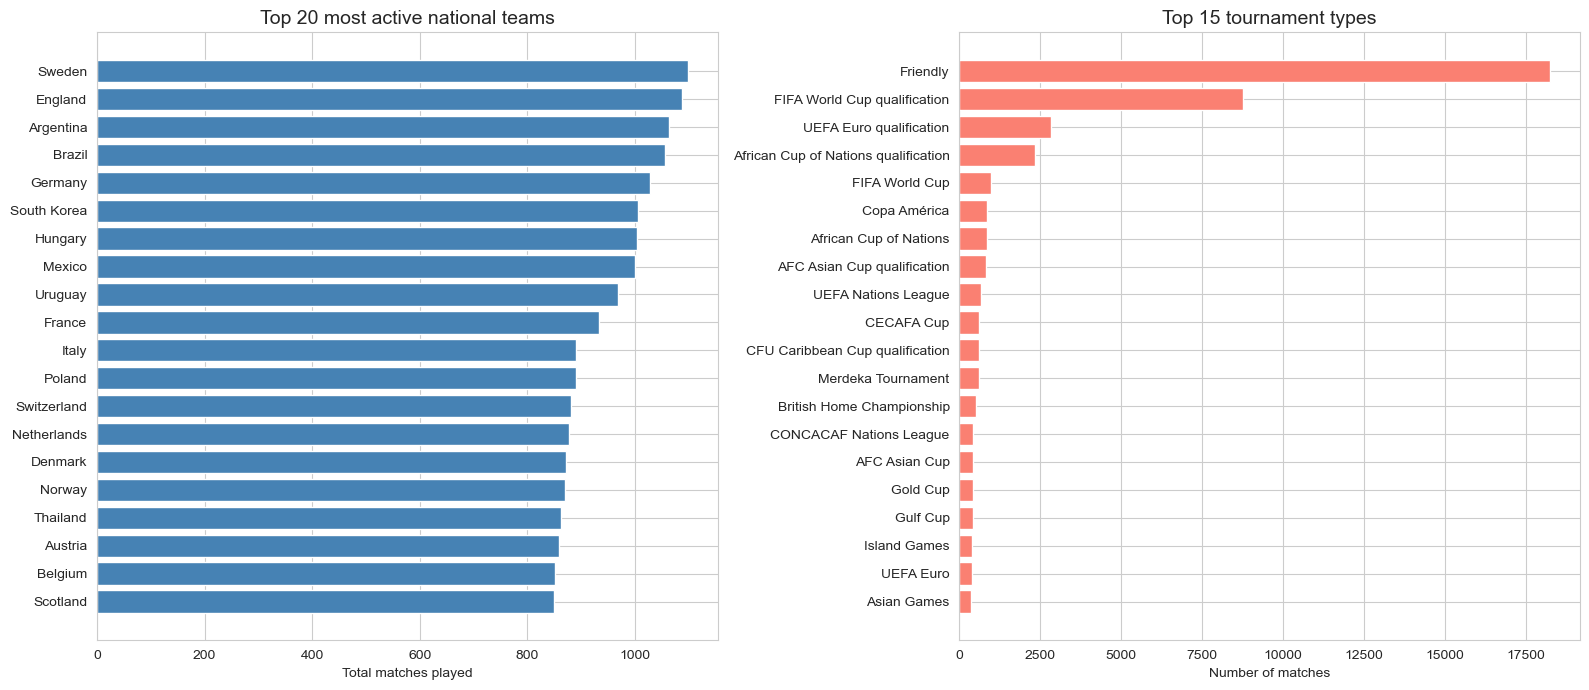


Friendly matches: 18252 (37.1%)
Competitive matches: 30963 (62.9%)


In [ ]:
# combine home and away appearances to count total matches per team
home_counts = df['home_team'].value_counts()
away_counts = df['away_team'].value_counts()
all_appearances = home_counts.add(away_counts, fill_value=0).sort_values(ascending=False)

print(f"Total unique teams in dataset: {len(all_appearances)}")
print(f"Median matches per team: {all_appearances.median():.0f}")

# plot top teams + top tournaments
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# top 20 most active national teams
top_teams = all_appearances.head(20)
axes[0].barh(top_teams.index[::-1], top_teams.values[::-1], color='steelblue')
axes[0].set_title("Top 20 most active national teams", fontsize=14)
axes[0].set_xlabel("Total matches played")

# top 20 tournament types
top_tournaments = df['tournament'].value_counts().head(20)
axes[1].barh(top_tournaments.index[::-1], top_tournaments.values[::-1], color='salmon')
axes[1].set_title("Top 20 tournament types", fontsize=14)
axes[1].set_xlabel("Number of matches")

plt.tight_layout()
plt.show()

# summary about friendlies vs competitive
n_friendly  = (df['tournament'] == 'Friendly').sum()
n_competitive = len(df) - n_friendly
print(f"\nFriendly matches: {n_friendly} ({n_friendly/len(df)*100:.1f}%)")
print(f"Competitive matches: {n_competitive} ({n_competitive/len(df)*100:.1f}%)")